# Trabalho de DL - Classificação de Imagens (CNN) - G13

### 1. Importar bibliotecas

In [1]:
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

!pip install torchinfo

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
from torchinfo import summary

In [2]:
# Garantir a reprodutibilidade
import random
import numpy as np

RAND_SEED = 13 #Em homenagem ao grupo!

random.seed(RAND_SEED)
np.random.seed(RAND_SEED)

torch.manual_seed(RAND_SEED)
torch.cuda.manual_seed(RAND_SEED)
torch.cuda.manual_seed_all(RAND_SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

g = torch.Generator()
g.manual_seed(RAND_SEED)

### 2. Macro definições

In [3]:
# ==========================
# Configurações
# ==========================
BATCH_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cuda


In [4]:
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(RAND_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

### 3. Transformações

In [5]:
# ==========================
# Transformações
# ==========================
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2023, 0.1994, 0.2010)
    )
])


### 4. Carregar o dataset

In [6]:

# ==========================
# Dataset e DataLoader
# ==========================

# ==========================
# Dataset completo
# ==========================
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test
)

# Se só houver CPU para rodar, então utiliza apenas 10% da base de treino/teste para agilizar
if DEVICE.type == 'cpu':
    # ====================================================
    # obtem os indices de apenas 10% da base para agilizar
    # ====================================================

    indices = range(len(train_dataset))
    labels = train_dataset.targets

    subset_idx, _ = train_test_split(
        list(indices),
        train_size=0.1,
        stratify=labels,
        random_state=RAND_SEED
    )

    train_subset = Subset(train_dataset, subset_idx)

    indices = range(len(test_dataset))
    labels = test_dataset.targets

    subset_idx, _ = train_test_split(
        list(indices),
        train_size=0.1,
        stratify=labels,
        random_state=RAND_SEED
    )

    test_subset = Subset(test_dataset, subset_idx)
else:
    train_subset = train_dataset
    test_subset = test_dataset


# ================================
# cria loader do treino e do teste
# ================================

train_loader = torch.utils.data.DataLoader(
    #train_dataset,
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    generator=g
)

test_loader = torch.utils.data.DataLoader(
    #test_dataset,
    test_subset,
    batch_size=len(test_subset), #batch único
    shuffle=False,
    num_workers=0,
    generator=g
)

In [7]:
# Sanity check
#num_data = len(train_l)
num_batch_train = len(train_loader)
num_batch_test = len(test_loader)
num_train = len(train_loader.dataset)
num_test = len(test_loader.dataset)

#print("Total of data: ", num_data)
print("Batch Size: ", BATCH_SIZE)
print("Number of batchs for training: ", num_batch_train)
print("Number of batchs for test: ", num_batch_test )
print("Number of samples on train: ", num_train)
print("Number of samples on test: ", num_test)

print("Total data = Num samples Train + Num samples on Test: ", num_train + num_test)

Batch Size:  128
Number of batchs for training:  391
Number of batchs for test:  1
Number of samples on train:  50000
Number of samples on test:  10000
Total data = Num samples Train + Num samples on Test:  60000


### 5. Definição das Classes

In [8]:
# Classes do CIFAR-10
classes = (
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
)

### 6. Definição do modelo (classe)

In [9]:
# ==========================
# Modelo CNN
# ==========================

class CNN(nn.Module):
    def __init__(self, input_shape, num_classes):
        """
        input_shape: (C, H, W)
        num_classes: número de classes (K)
        """
        super().__init__()

        # Estágio 1
        self.features = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=3, stride=2),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2),
            nn.ReLU(),
        )

        # Calcula automaticamente o tamanho após as convoluções
        with torch.no_grad():
            x = torch.zeros(1, *input_shape)
            x = self.features(x)
            flattened_size = x.view(1, -1).size(1)

        # Estágio 2
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(flattened_size, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x
    
model = CNN((3,32,32), 10).to(DEVICE)


In [10]:
model

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
    (5): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=1152, out_features=1024, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=1024, out_features=10, bias=True)
  )
)

In [11]:
summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 3, 3]            --
│    └─Conv2d: 2-1                       [1, 32, 15, 15]           896
│    └─ReLU: 2-2                         [1, 32, 15, 15]           --
│    └─Conv2d: 2-3                       [1, 64, 7, 7]             18,496
│    └─ReLU: 2-4                         [1, 64, 7, 7]             --
│    └─Conv2d: 2-5                       [1, 128, 3, 3]            73,856
│    └─ReLU: 2-6                         [1, 128, 3, 3]            --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-7                      [1, 1152]                 --
│    └─Dropout: 2-8                      [1, 1152]                 --
│    └─Linear: 2-9                       [1, 1024]                 1,180,672
│    └─ReLU: 2-10                        [1, 1024]                 --

### 7. Função de perda e otimizador

In [12]:
# ==========================
# Função de perda e otimizador
# ==========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

### 8. Treinamento e Avaliação

In [13]:
# ==========================
# Treinamento e Avaliação
# ==========================
train_acc_history = []
test_acc_history = []
train_loss_history = []

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    train_acc_history.append(train_acc)
    train_loss_history.append(train_loss)

    # Avaliação
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            _, predicted = outputs.max(1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_acc = 100 * correct / total
    test_acc_history.append(test_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"Loss={train_loss:.4f} "
        f"Train={train_acc:.2f}% "
        f"Test={test_acc:.2f}%"
    )

Epoch 1/15 Loss=1.7158 Train=36.78% Test=49.26%
Epoch 2/15 Loss=1.4517 Train=46.92% Test=55.89%
Epoch 3/15 Loss=1.3201 Train=52.54% Test=57.58%
Epoch 4/15 Loss=1.2346 Train=55.55% Test=61.60%
Epoch 5/15 Loss=1.1654 Train=58.29% Test=64.95%
Epoch 6/15 Loss=1.1148 Train=60.41% Test=65.72%
Epoch 7/15 Loss=1.0739 Train=61.79% Test=68.18%
Epoch 8/15 Loss=1.0466 Train=62.55% Test=69.46%
Epoch 9/15 Loss=1.0137 Train=64.03% Test=70.11%
Epoch 10/15 Loss=0.9882 Train=65.13% Test=71.40%
Epoch 11/15 Loss=0.9719 Train=65.70% Test=72.17%
Epoch 12/15 Loss=0.9591 Train=66.20% Test=73.24%
Epoch 13/15 Loss=0.9312 Train=67.22% Test=73.22%
Epoch 14/15 Loss=0.9193 Train=67.59% Test=74.40%
Epoch 15/15 Loss=0.9083 Train=67.90% Test=73.99%


### 9. Mostrando no gráfico

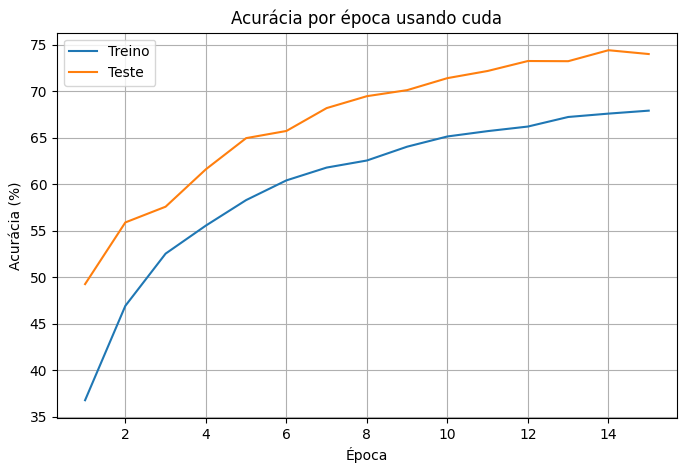

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame({
    "epoch": range(1, EPOCHS + 1),
    "train_loss": train_loss_history,
    "train_acc": train_acc_history,
    "test_acc": test_acc_history
})


plt.figure(figsize=(8, 5))
plt.plot(history["epoch"], history["train_acc"], label="Treino")
plt.plot(history["epoch"], history["test_acc"], label="Teste")

plt.xlabel("Época")
plt.ylabel("Acurácia (%)")
plt.title(f"Acurácia por época usando {DEVICE.type}")
plt.legend()
plt.grid(True)

plt.show()

### 10. Salvar o modelo

In [15]:
# ==========================
# Salvar modelo
# ==========================
torch.save(model.state_dict(), "cifar10_model.pth")
print("Modelo salvo em cifar10_model.pth")

Modelo salvo em cifar10_model.pth
